SETUP

In [1]:
# If on Colab, mount Drive first
from google.colab import drive
drive.mount('/content/drive')

# Then clone/pull repo (your usual cells)
import os
REPO = "LaneDetection"
if not os.path.exists(f"/content/{REPO}"):
    !git clone https://github.com/abdullahtapanci/LaneDetection.git /content/{REPO}
else:
    !cd /content/{REPO} && git pull
%cd /content/{REPO}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
/content/LaneDetection


IMPORT AND LOAD MODEL

In [ ]:
import os, time, cv2, torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import src.config as cfg
from src.models.lanenet import LaneNet, LaneNetResNet34
from src.postprocess import my_postprocess, draw_lanes, binary_mask_to_lanes

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

#Checkpoint path
CKPT_PATH = "/content/drive/MyDrive/Lane_Detection_Project/checkpoints/6/best.pt"

#Load the model
#model = LaneNet(embedding_dim=4).to(device)
#Load the LaneNetResNet34
model = LaneNetResNet34(embedding_dim=4).to(device)
#Load the checkpoint
ckpt  = torch.load(CKPT_PATH, map_location=device)
#Load the model state dict from the checkpoint. Model state dict maps each layer in your network to its specific 
#tensors (the weight and bias values).
# #It is like:
# {
#     'encoder.layer1.weight': tensor([[ 0.12, -0.05, ...], ...]),
#     'encoder.layer1.bias':   tensor([ 0.01,  0.03, ...]),
#     ...
# }
model.load_state_dict(ckpt['model_state_dict'])
#Set the model to evaluation mode. In this mode the dropout and batch normalization layers will not be used. It switches
#the model from training mode to evaluation mode. All neurons are kept active to get the most accurate prediction. Even if we 
#pass in a single image, the normalization is consistent with the whole dataset.
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

device: cpu
Loaded checkpoint from epoch 14


PREPROCESS FRAMES

In [3]:
#This is the same preprocessing as src/data/transforms.py, but for an in-memory frame
_IMNET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
_IMNET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_frame(frame_bgr, target_w=cfg.IMAGE_WIDTH, target_h=cfg.IMAGE_HEIGHT):
    """frame_bgr: (Ho, Wo, 3) uint8 from cv2.VideoCapture.
       Returns: tensor (1, 3, H, W) ready for the model + the resized RGB frame."""
    frame = cv2.resize(frame_bgr, (target_w, target_h))
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    f = frame_rgb.astype(np.float32) / 255.0
    f = (f - _IMNET_MEAN) / _IMNET_STD
    t = torch.from_numpy(f).permute(2, 0, 1).unsqueeze(0)   # (1, 3, H, W)
    return t, frame_rgb

THIS PART IS FOR TESTING IMAGES

binary_logits shape=(2, 384, 768)  range=[-20.87, 20.65]
embedding     shape=(4, 384, 768)     range=[-2.49, 3.84]
Pred lane pixels: 13,276 / 294,912 (4.50%)
Detected 4 lanes
  Lane 0: poly=[ 1.700000e-02 -9.250000e+00  1.348358e+03]  y_range=(146, 249)  n_pixels=2470
  Lane 1: poly=[ 1.00000e-03 -1.61900e+00  6.02973e+02]  y_range=(146, 373)  n_pixels=3187
  Lane 2: poly=[ -0.      1.367 219.008]  y_range=(146, 383)  n_pixels=4550
  Lane 3: poly=[-1.10000e-02  7.34000e+00 -3.75867e+02]  y_range=(163, 197)  n_pixels=1080


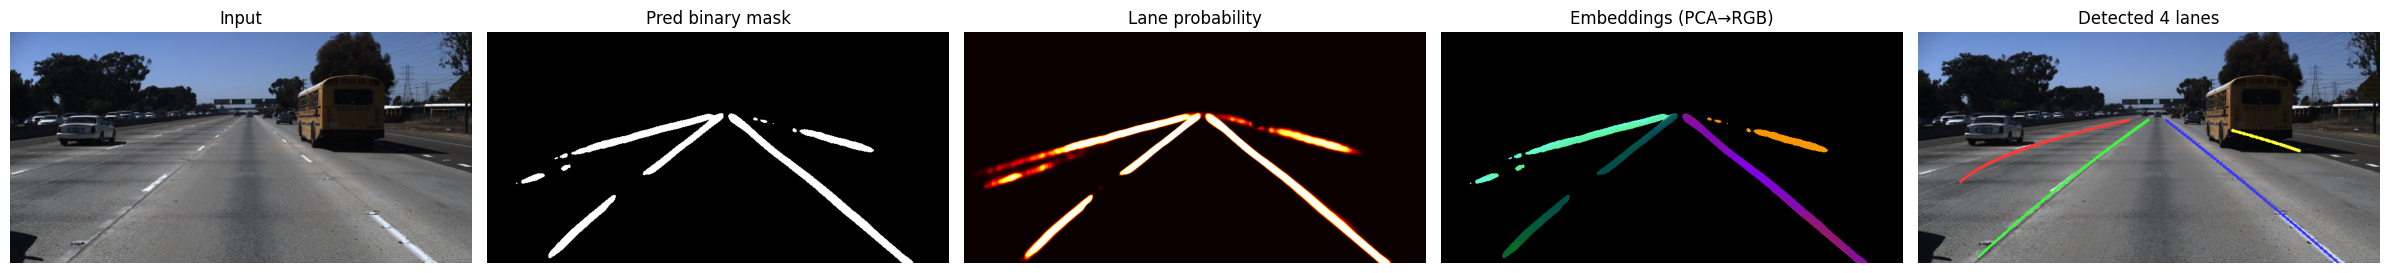

In [4]:
from sklearn.decomposition import PCA

IMAGE_PATH = "/content/drive/MyDrive/Lane_Detection_Project/sampleImages/testImage3.png"
# IMAGE_PATH = "samples/test.jpg"   # local

#These are postprocess hyperparameters — we can tune these per trained model
#EPS is the maximum distance between two samples for them to be considered as in the same neighborhood.
#MIN_SAMPLES is the minimum number of samples required to form a dense region (i.e., a lane).
#MIN_PIXELS is the minimum number of pixels required for a detected lane to be considered valid.
EPS, MIN_SAMPLES, MIN_PIXELS, BANDWIDTH = 1.0, 20, 100, 1.5
POLY_DEGREE = 2
HORIZON_CUTOFF = 0
HORIZON_PADDING = 0
MIN_BLOB_PIXELS = 10
THRESHOLD = 0.7

# --- Read image ---
frame_bgr = cv2.imread(IMAGE_PATH)
assert frame_bgr is not None, f"Cannot open image: {IMAGE_PATH}"

# --- Preprocess + run model ---
x, frame_rgb = preprocess_frame(frame_bgr)
with torch.no_grad():
    binary_logits, embedding = model(x.to(device))

# --- Postprocess ---
binary_np = binary_logits.squeeze(0).cpu().numpy()    # (2, H, W)
emb_np    = embedding.squeeze(0).cpu().numpy()         # (D, H, W)

# lanes = my_postprocess(binary_np, emb_np,
#                        eps=EPS, min_samples=MIN_SAMPLES, threshold=THRESHOLD,
#                        poly_degree=POLY_DEGREE, min_pixels=MIN_PIXELS, bandwidth=BANDWIDTH, clustering_algorithm='meanshift', 
#                        horizon_min_pixels=HORIZON_CUTOFF, horizon_padding=HORIZON_PADDING, min_blob_pixels=MIN_BLOB_PIXELS)

lanes = my_postprocess(
    binary_np,
    emb_np,
    threshold=THRESHOLD,
    bandwidth=0.35,
    min_pixels=MIN_PIXELS,
    clustering_algorithm="meanshift",
    normalize_embeddings=True,
    use_coordinates=True,
    coord_weight=0.25,
    min_blob_pixels=MIN_BLOB_PIXELS,
)


# --- Pull intermediates for visualization ---
binary_pred = binary_np.argmax(axis=0).astype(np.uint8)                # (H, W)
binary_prob = torch.softmax(binary_logits, dim=1)[0, 1].cpu().numpy()  # lane prob

# Stats
print(f"binary_logits shape={binary_np.shape}  range=[{binary_np.min():.2f}, {binary_np.max():.2f}]")
print(f"embedding     shape={emb_np.shape}     range=[{emb_np.min():.2f}, {emb_np.max():.2f}]")
print(f"Pred lane pixels: {binary_pred.sum():,} / {binary_pred.size:,} "
      f"({100*binary_pred.mean():.2f}%)")
print(f"Detected {len(lanes)} lanes")
for i, l in enumerate(lanes):
    print(f"  Lane {i}: poly={l['poly'].round(3)}  y_range={l['y_range']}  "
          f"n_pixels={len(l['pixels'])}")

# --- Embedding PCA → RGB (only at predicted lane pixels) ---
D, H, W = emb_np.shape
emb_flat = emb_np.reshape(D, -1).T
lane_mask = binary_pred.astype(bool).flatten()
emb_rgb = np.zeros((H * W, 3), dtype=np.float32)
if lane_mask.sum() >= 3:
    pca = PCA(n_components=3).fit_transform(emb_flat[lane_mask])
    pca -= pca.min(axis=0); pca /= pca.max(axis=0) + 1e-8
    emb_rgb[lane_mask] = pca
emb_rgb = emb_rgb.reshape(H, W, 3)

# --- Draw lanes ---
annotated = draw_lanes(frame_rgb.copy(), lanes)

# --- 5-panel visualization ---
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
axes[0].imshow(frame_rgb);                                axes[0].set_title("Input")
axes[1].imshow(binary_pred, cmap="gray");                 axes[1].set_title("Pred binary mask")
axes[2].imshow(binary_prob, cmap="hot", vmin=0, vmax=1);  axes[2].set_title("Lane probability")
axes[3].imshow(emb_rgb);                                  axes[3].set_title("Embeddings (PCA→RGB)")
axes[4].imshow(annotated);                                axes[4].set_title(f"Detected {len(lanes)} lanes")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

THIS PART CONTAINS REAL TIME VIDEO PROCESSING

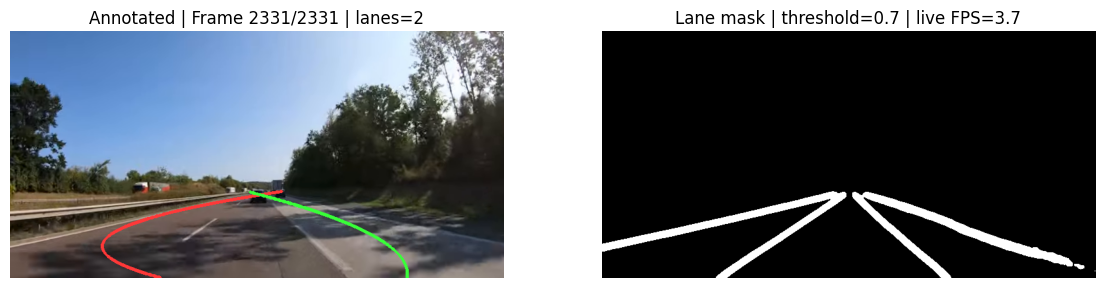

Done.


In [ ]:
VIDEO_PATH = "/content/drive/MyDrive/Lane_Detection_Project/sampleVideos/testVideo3.mov"

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open video: {VIDEO_PATH}"

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_in = cap.get(cv2.CAP_PROP_FPS)

print(f"Video: {total_frames} frames, source FPS ~{fps_in:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    ax.axis("off")

frame_idx = 0
t_start = time.time()

model.eval()

def lanes_to_segmentation_mask(lanes, height, width):
    seg_mask = np.zeros((height, width), dtype=np.uint8)

    for lane_id, lane in enumerate(lanes, start=1):
        pts = np.asarray(lane)

        if pts.size == 0:
            continue

        pts = pts.astype(np.int32)

        if pts.ndim != 2 or pts.shape[1] != 2:
            continue

        xs = np.clip(pts[:, 0], 0, width - 1)
        ys = np.clip(pts[:, 1], 0, height - 1)

        seg_mask[ys, xs] = lane_id

    return seg_mask

with torch.no_grad():
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break

        x, frame_rgb = preprocess_frame(frame_bgr)
        x = x.to(device)

        binary_logits, embedding = model(x)

        binary_np = binary_logits.squeeze(0).cpu().numpy()
        emb_np = embedding.squeeze(0).cpu().numpy()

        lanes = my_postprocess(
            binary_np,
            emb_np,
            threshold=THRESHOLD,
            bandwidth=0.35,
            min_pixels=MIN_PIXELS,
            clustering_algorithm="meanshift",
            normalize_embeddings=True,
            use_coordinates=True,
            coord_weight=0.25,
            min_blob_pixels=MIN_BLOB_PIXELS,
        )

        annotated = draw_lanes(frame_rgb.copy(), lanes)

        probs = torch.softmax(binary_logits, dim=1)[0, 1]
        lane_mask = (probs > THRESHOLD).detach().cpu().numpy().astype(np.uint8) * 255

        h, w = lane_mask.shape
        seg_mask = lanes_to_segmentation_mask(lanes, h, w)

        axes[0].clear()
        axes[1].clear()
        axes[2].clear()

        for ax in axes:
            ax.axis("off")

        elapsed = time.time() - t_start
        live_fps = (frame_idx + 1) / elapsed if elapsed > 0 else 0

        axes[0].imshow(annotated)
        axes[0].set_title(
            f"Annotated | Frame {frame_idx + 1}/{total_frames} | lanes={len(lanes)}"
        )

        axes[1].imshow(lane_mask, cmap="gray", vmin=0, vmax=255)
        axes[1].set_title(f"Binary mask | threshold={THRESHOLD}")

        axes[2].imshow(seg_mask, cmap="tab10", vmin=0, vmax=10)
        axes[2].set_title(f"Segmentation mask | live FPS={live_fps:.1f}")

        clear_output(wait=True)
        display(fig)

        frame_idx += 1

cap.release()
plt.close(fig)

print("Done.")


HERE WE CAN SAVE THE FILE INSTEAD OF LIVE STREAM

In [ ]:
import cv2
import torch

EPS         = 0.5
MIN_SAMPLES = 50
MIN_PIXELS  = 100

INPUT      = "/content/drive/MyDrive/Lane_Detection_Project/sampleVideos/testVideo3.mov"  # input still in Drive
LOCAL_OUT  = "/content/lanes_annotated.mp4"   # output stays local in Colab

cap = cv2.VideoCapture(INPUT)
assert cap.isOpened(), f"Cannot open {INPUT}"
fps_in       = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Input: {total_frames} frames at {fps_in:.1f} FPS")

writer = None
i = 0
with torch.no_grad():
    while True:
        ok, frame_bgr = cap.read()
        if not ok: break

        x, frame_rgb = preprocess_frame(frame_bgr)
        x = x.to(device)
        binary_logits, embedding = model(x)

        binary_np = binary_logits.squeeze(0).cpu().numpy()
        emb_np    = embedding.squeeze(0).cpu().numpy()
        lanes = my_postprocess(
            binary_np,
            emb_np,
            threshold=THRESHOLD,
            bandwidth=0.35,
            min_pixels=MIN_PIXELS,
            clustering_algorithm="meanshift",
            normalize_embeddings=True,
            use_coordinates=True,
            coord_weight=0.25,
            min_blob_pixels=MIN_BLOB_PIXELS,
        )
        annotated = draw_lanes(frame_rgb.copy(), lanes)
        annotated_bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)

        if writer is None:
            h, w = annotated_bgr.shape[:2]
            writer = cv2.VideoWriter(LOCAL_OUT,
                                     cv2.VideoWriter_fourcc(*'mp4v'),
                                     fps_in, (w, h))
        writer.write(annotated_bgr)

        i += 1
        if i % 30 == 0:
            print(f"  {i}/{total_frames} frames")

cap.release()
if writer: writer.release()
print(f"Saved to {LOCAL_OUT} ({os.path.getsize(LOCAL_OUT)/1024/1024:.1f} MB)")

# Trigger browser download to your Mac
from google.colab import files
files.download(LOCAL_OUT)

Input: 2331 frames at 43.1 FPS
  30/2331 frames
  60/2331 frames
  90/2331 frames
  120/2331 frames
  150/2331 frames
  180/2331 frames
  210/2331 frames
  240/2331 frames
  270/2331 frames
  300/2331 frames
  330/2331 frames
  360/2331 frames
  390/2331 frames
  420/2331 frames
  450/2331 frames
  480/2331 frames
  510/2331 frames
  540/2331 frames
  570/2331 frames
  600/2331 frames
  630/2331 frames
  660/2331 frames
  690/2331 frames
  720/2331 frames
  750/2331 frames
  780/2331 frames
  810/2331 frames
  840/2331 frames
  870/2331 frames
  900/2331 frames
  930/2331 frames
  960/2331 frames
  990/2331 frames
  1020/2331 frames
  1050/2331 frames
  1080/2331 frames
  1110/2331 frames
  1140/2331 frames
  1170/2331 frames
  1200/2331 frames
  1230/2331 frames
  1260/2331 frames
  1290/2331 frames
  1320/2331 frames
  1350/2331 frames
  1380/2331 frames
  1410/2331 frames
  1440/2331 frames
  1470/2331 frames
  1500/2331 frames
  1530/2331 frames
  1560/2331 frames
  1590/2331 frame

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

THREE PANEL OUTPUT

In [ ]:
import os
import cv2
import torch
import numpy as np


EPS         = 0.5
MIN_SAMPLES = 50
MIN_PIXELS  = 100

INPUT      = "/content/drive/MyDrive/Lane_Detection_Project/sampleVideos/testVideo3.mov"
LOCAL_OUT  = "/content/lanes_annotated_with_masks.mp4"

cap = cv2.VideoCapture(INPUT)
assert cap.isOpened(), f"Cannot open {INPUT}"

fps_in = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Input: {total_frames} frames at {fps_in:.1f} FPS")

def lanes_to_instance_mask(lanes, height, width, thickness=6):
    mask = np.zeros((height, width), dtype=np.uint8)

    for lane_id, lane in enumerate(lanes, start=1):
        y_min, y_max = lane["y_range"]

        ys = np.arange(y_min, y_max + 1).astype(np.int32)
        xs = np.polyval(lane["poly"], ys).astype(np.int32)

        valid = (xs >= 0) & (xs < width) & (ys >= 0) & (ys < height)
        xs = xs[valid]
        ys = ys[valid]

        if len(xs) < 2:
            continue

        pts = np.stack([xs, ys], axis=1).reshape(-1, 1, 2)

        cv2.polylines(
            mask,
            [pts],
            isClosed=False,
            color=lane_id,
            thickness=thickness,
        )

    return mask


def colorize_instance_mask(instance_mask):
    color_table = np.array([
        [0, 0, 0],
        [255, 0, 0],
        [0, 255, 0],
        [0, 128, 255],
        [255, 255, 0],
        [255, 0, 255],
        [0, 255, 255],
        [255, 128, 0],
        [128, 0, 255],
        [128, 255, 0],
    ], dtype=np.uint8)

    ids = instance_mask % len(color_table)
    return color_table[ids]

def make_title_bar(image_rgb, title, height=36):
    h, w = image_rgb.shape[:2]
    bar = np.zeros((height, w, 3), dtype=np.uint8)
    bar[:] = (25, 25, 25)

    cv2.putText(
        bar,
        title,
        (12, 24),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    return np.vstack([bar, image_rgb])

writer = None
i = 0

model.eval()

with torch.no_grad():
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break

        x, frame_rgb = preprocess_frame(frame_bgr)
        x = x.to(device)

        binary_logits, embedding = model(x)

        binary_np = binary_logits.squeeze(0).cpu().numpy()
        emb_np = embedding.squeeze(0).cpu().numpy()

        # lanes = my_postprocess(
        #     binary_np,
        #     emb_np,
        #     threshold=THRESHOLD,
        #     bandwidth=0.35,
        #     min_pixels=MIN_PIXELS,
        #     clustering_algorithm="meanshift",
        #     normalize_embeddings=True,
        #     use_coordinates=True,
        #     coord_weight=0.25,
        #     min_blob_pixels=MIN_BLOB_PIXELS,
        # )

        lanes, binary_mask = binary_mask_to_lanes(
            binary_np,
            threshold=THRESHOLD,
            min_blob_pixels=MIN_BLOB_PIXELS,
            min_lane_pixels=MIN_PIXELS,
            poly_degree=POLY_DEGREE,
            horizon_min_pixels=HORIZON_CUTOFF,
            horizon_padding=HORIZON_PADDING,
        )

        annotated = draw_lanes(frame_rgb.copy(), lanes)

        probs = torch.softmax(binary_logits, dim=1)[0, 1]
        binary_mask = (probs > 0.5).detach().cpu().numpy().astype(np.uint8) * 255
        binary_mask_rgb = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB)

        h, w = binary_mask.shape
        instance_mask = lanes_to_instance_mask(lanes, h, w, thickness=6)
        instance_mask_rgb = colorize_instance_mask(instance_mask)

        annotated_panel = make_title_bar(annotated, "Annotated")
        binary_panel = make_title_bar(binary_mask_rgb, "Binary mask")
        instance_panel = make_title_bar(instance_mask_rgb, "Instance mask")

        combined_rgb = np.hstack([
            annotated_panel,
            binary_panel,
            instance_panel,
        ])

        combined_bgr = cv2.cvtColor(combined_rgb, cv2.COLOR_RGB2BGR)

        if writer is None:
            out_h, out_w = combined_bgr.shape[:2]
            writer = cv2.VideoWriter(
                LOCAL_OUT,
                cv2.VideoWriter_fourcc(*"mp4v"),
                fps_in,
                (out_w, out_h),
            )

        writer.write(combined_bgr)

        i += 1
        if i % 30 == 0:
            print(f"  {i}/{total_frames} frames")

cap.release()

if writer:
    writer.release()

print(f"Saved to {LOCAL_OUT} ({os.path.getsize(LOCAL_OUT) / 1024 / 1024:.1f} MB)")

from google.colab import files
files.download(LOCAL_OUT)


Input: 2331 frames at 43.1 FPS
  30/2331 frames
  60/2331 frames
  90/2331 frames
  120/2331 frames
  150/2331 frames
  180/2331 frames
  210/2331 frames
  240/2331 frames
  270/2331 frames
  300/2331 frames
  330/2331 frames
  360/2331 frames
  390/2331 frames
  420/2331 frames
  450/2331 frames
  480/2331 frames
  510/2331 frames
  540/2331 frames
  570/2331 frames
  600/2331 frames
  630/2331 frames
  660/2331 frames
  690/2331 frames
  720/2331 frames
  750/2331 frames
  780/2331 frames
  810/2331 frames
  840/2331 frames
  870/2331 frames
  900/2331 frames
  930/2331 frames
  960/2331 frames
  990/2331 frames
  1020/2331 frames
  1050/2331 frames
  1080/2331 frames
  1110/2331 frames
  1140/2331 frames
  1170/2331 frames
  1200/2331 frames
  1230/2331 frames
  1260/2331 frames
  1290/2331 frames
  1320/2331 frames
  1350/2331 frames
  1380/2331 frames
  1410/2331 frames
  1440/2331 frames
  1470/2331 frames
  1500/2331 frames
  1530/2331 frames
  1560/2331 frames
  1590/2331 frame

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

COPY THE VIDEO TO THE DRIVE

In [6]:
import shutil
shutil.copy(LOCAL_OUT, "/content/drive/MyDrive/lanes_annotated.mp4")

'/content/drive/MyDrive/lanes_annotated.mp4'

TestSet video 

In [9]:
import cv2
import os
import glob

CLIPS_ROOT = "/content/drive/MyDrive/Lane_Detection_Project/data/tusimple/test_set/clips"
OUTPUT_DIR = "/content/tusimple_videos"
FPS        = 20
N_FRAMES   = 20   # TuSimple clips have 20 frames each

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Find all clip folders (each contains 1.jpg through 20.jpg)
clip_dirs = sorted(glob.glob(f"{CLIPS_ROOT}/*/*"))
print(f"Found {len(clip_dirs)} clip folders")

for i, clip_dir in enumerate(clip_dirs[:5]):   # first 5 clips for now
    # Read frames in numerical order
    frames = []
    for n in range(1, N_FRAMES + 1):
        path = os.path.join(clip_dir, f"{n}.jpg")
        if os.path.exists(path):
            frames.append(cv2.imread(path))

    if not frames:
        continue

    h, w = frames[0].shape[:2]
    name = clip_dir.replace(CLIPS_ROOT, "").replace("/", "_").strip("_")
    out_path = os.path.join(OUTPUT_DIR, f"{name}.mp4")

    writer = cv2.VideoWriter(out_path,
                             cv2.VideoWriter_fourcc(*'mp4v'),
                             FPS, (w, h))
    for f in frames:
        writer.write(f)
    writer.release()

    print(f"  [{i+1}] Saved {out_path} ({len(frames)} frames)")

print(f"\nDone. Videos in {OUTPUT_DIR}")

In [10]:
# After running the above, combine N clips into one longer video
import glob

clip_videos = sorted(glob.glob(f"{OUTPUT_DIR}/*.mp4"))[:10]   # take first 10
print(f"Combining {len(clip_videos)} clips...")

# Read first frame to get dimensions
cap = cv2.VideoCapture(clip_videos[0])
ret, frame = cap.read()
h, w = frame.shape[:2]
cap.release()

big_writer = cv2.VideoWriter(f"{OUTPUT_DIR}/highway_combined.mp4",
                             cv2.VideoWriter_fourcc(*'mp4v'),
                             FPS, (w, h))

for vp in clip_videos:
    cap = cv2.VideoCapture(vp)
    while True:
        ok, f = cap.read()
        if not ok: break
        big_writer.write(f)
    cap.release()

big_writer.release()
print("Done — highway_combined.mp4 is ~10 seconds of dashcam footage")

In [12]:
import shutil
shutil.copy("/content/tusimple_videos/highway_combined.mp4",
            "/content/drive/MyDrive/Lane_Detection_Project/highway_combined.mp4")